In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import os
load_dotenv()


True

In [10]:
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)

In [11]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [12]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [22]:
def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [23]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

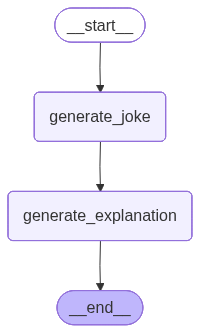

In [20]:
workflow

In [24]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza make a terrible comedian?\n\nBecause all its jokes were too **cheesy**!',
 'explanation': 'This joke is a classic example of a **pun**! It plays on the double meaning of the word "cheesy."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (related to pizza):** Pizza is, by definition, covered in **cheese**. So, in a very straightforward sense, a pizza is "cheesy."\n\n2.  **Figurative Meaning (related to comedy/jokes):** When we describe a joke, a movie, or a performance as "**cheesy**," it means it\'s:\n    *   Unoriginal or predictable\n    *   Trying too hard to be funny or sentimental\n    *   A bit corny, cliché, or groan-worthy\n    *   Lacking genuine wit or sophistication\n\nThe humor comes from the unexpected connection between these two meanings. The joke sets you up to think about pizza literally having cheese. But then, the punchline cleverly twists "cheesy" to its figurative meaning in the context of a comedian\'s bad jokes.\n

In [25]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza make a terrible comedian?\n\nBecause all its jokes were too **cheesy**!', 'explanation': 'This joke is a classic example of a **pun**! It plays on the double meaning of the word "cheesy."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (related to pizza):** Pizza is, by definition, covered in **cheese**. So, in a very straightforward sense, a pizza is "cheesy."\n\n2.  **Figurative Meaning (related to comedy/jokes):** When we describe a joke, a movie, or a performance as "**cheesy**," it means it\'s:\n    *   Unoriginal or predictable\n    *   Trying too hard to be funny or sentimental\n    *   A bit corny, cliché, or groan-worthy\n    *   Lacking genuine wit or sophistication\n\nThe humor comes from the unexpected connection between these two meanings. The joke sets you up to think about pizza literally having cheese. But then, the punchline cleverly twists "cheesy" to its figurative meaning in the context of a comed

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza make a terrible comedian?\n\nBecause all its jokes were too **cheesy**!', 'explanation': 'This joke is a classic example of a **pun**! It plays on the double meaning of the word "cheesy."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (related to pizza):** Pizza is, by definition, covered in **cheese**. So, in a very straightforward sense, a pizza is "cheesy."\n\n2.  **Figurative Meaning (related to comedy/jokes):** When we describe a joke, a movie, or a performance as "**cheesy**," it means it\'s:\n    *   Unoriginal or predictable\n    *   Trying too hard to be funny or sentimental\n    *   A bit corny, cliché, or groan-worthy\n    *   Lacking genuine wit or sophistication\n\nThe humor comes from the unexpected connection between these two meanings. The joke sets you up to think about pizza literally having cheese. But then, the punchline cleverly twists "cheesy" to its figurative meaning in the context of a come

In [27]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'What do you call fake spaghetti?\nAn **impasta!**',
 'explanation': 'This joke is a classic example of a **pun**, which relies on wordplay. Here\'s the breakdown:\n\n1.  **The Setup:** "What do you call fake spaghetti?"\n    *   The key word here is "fake." We\'re looking for something that pretends to be spaghetti but isn\'t real.\n\n2.  **The Punchline:** "An **impasta!**"\n\n3.  **The Pun Explained:**\n    *   The word "**impasta**" sounds almost exactly like the word "**imposter**."\n    *   An **imposter** is a person who pretends to be someone else in order to deceive others; a fake.\n    *   **Pasta** is the general term for food like spaghetti.\n\n4.  **The Humor:** The joke cleverly combines the idea of something being "fake" (like an imposter) with the food itself ("pasta"). So, "impasta" is a playful way to say "fake pasta," just as an imposter is a fake person. The humor comes from the unexpected but perfectly fitting wordplay.'}

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza make a terrible comedian?\n\nBecause all its jokes were too **cheesy**!', 'explanation': 'This joke is a classic example of a **pun**! It plays on the double meaning of the word "cheesy."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (related to pizza):** Pizza is, by definition, covered in **cheese**. So, in a very straightforward sense, a pizza is "cheesy."\n\n2.  **Figurative Meaning (related to comedy/jokes):** When we describe a joke, a movie, or a performance as "**cheesy**," it means it\'s:\n    *   Unoriginal or predictable\n    *   Trying too hard to be funny or sentimental\n    *   A bit corny, cliché, or groan-worthy\n    *   Lacking genuine wit or sophistication\n\nThe humor comes from the unexpected connection between these two meanings. The joke sets you up to think about pizza literally having cheese. But then, the punchline cleverly twists "cheesy" to its figurative meaning in the context of a come

TIME TRAVEl

In [29]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id":"1f15f789-317f-60e4-8000-a77d95f65888" }})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f15f789-317f-60e4-8000-a77d95f65888'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-03T18:18:09.372970+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15f789-317a-6a57-bfff-284ffc42eb50'}}, tasks=(PregelTask(id='70f6a63e-33d3-4b24-8f6f-70aa925aec28', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza make a terrible comedian?\n\nBecause all its jokes were too **cheesy**!'}),), interrupts=())

In [30]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f15f789-317f-60e4-8000-a77d95f65888"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a bank loan?\n\nBecause it was a little short on **dough**!',
 'explanation': 'This joke is a pun, which means it plays on the double meaning of a word.\n\nHere\'s the breakdown:\n\n1.  **"Short on dough" (Meaning 1: Money):** In informal English, "dough" is a slang term for **money**. If someone is "short on dough," it means they don\'t have enough money, which is why they would need a bank loan.\n\n2.  **"Dough" (Meaning 2: Food):** A pizza is literally made from **dough** – the mixture of flour, water, and yeast that forms its crust.\n\nThe humor comes from the unexpected switch:\n*   The setup (a pizza needing a bank loan) makes you think of the *money* meaning of "dough."\n*   The punchline uses "dough" in a way that *also* literally applies to a pizza (it\'s made of dough), creating a silly image of a pizza being incomplete or lacking its fundamental ingredient, while simultaneously implying it lacks money.\n\nSo, the pizza

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a bank loan?\n\nBecause it was a little short on **dough**!', 'explanation': 'This joke is a pun, which means it plays on the double meaning of a word.\n\nHere\'s the breakdown:\n\n1.  **"Short on dough" (Meaning 1: Money):** In informal English, "dough" is a slang term for **money**. If someone is "short on dough," it means they don\'t have enough money, which is why they would need a bank loan.\n\n2.  **"Dough" (Meaning 2: Food):** A pizza is literally made from **dough** – the mixture of flour, water, and yeast that forms its crust.\n\nThe humor comes from the unexpected switch:\n*   The setup (a pizza needing a bank loan) makes you think of the *money* meaning of "dough."\n*   The punchline uses "dough" in a way that *also* literally applies to a pizza (it\'s made of dough), creating a silly image of a pizza being incomplete or lacking its fundamental ingredient, while simultaneously implying it lacks mon

In [32]:
workflow.update_state({"configurable":{"thread_id": "1", "checkpoint_id": "1f15f791-7e69-6a39-8001-020f7f89c755", "checkpoint_ns": ""}}, {"topic":"mango"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15f796-4ece-62c9-8002-acc06926a563'}}

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'mango'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15f796-4ece-62c9-8002-acc06926a563'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-06-03T18:24:01.412347+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15f791-7e69-6a39-8001-020f7f89c755'}}, tasks=(PregelTask(id='54f57ac0-8b86-3e62-79e7-3141f754bcdf', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a bank loan?\n\nBecause it was a little short on **dough**!', 'explanation': 'This joke is a pun, which means it plays on the double meaning of a word.\n\nHere\'s the breakdown:\n\n1.  **"Short on dough" (Meaning 1: Money):** In informal English, "dough" is a slang term for **money**. If someone is "sh

In [34]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f15f796-4ece-62c9-8002-acc06926a563"}})

{'topic': 'mango',
 'joke': "Why did the mango break up with the other fruit?\n\nBecause it just couldn't **man-go** anymore!",
 'explanation': 'This joke is a classic **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **The Fruit:** The joke is about a **mango**.\n2.  **The Pun:** The punchline uses the phrase "**man-go**," which sounds exactly like the fruit "mango."\n3.  **The Implied Meaning:** "Man-go" in this context is a play on:\n    *   "**Man up and go**" (meaning to face a challenge or continue despite difficulty).\n    *   More directly, "couldn\'t **manage to go** (on)" or "couldn\'t **continue**" any longer.\n\nSo, the humor comes from the silly idea that the mango fruit, named "mango," literally "couldn\'t man-go anymore" – meaning it couldn\'t handle the relationship or just couldn\'t continue it any longer, using its own name as the reason. It\'s a playful twist of words!'}

In [35]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'mango', 'joke': "Why did the mango break up with the other fruit?\n\nBecause it just couldn't **man-go** anymore!", 'explanation': 'This joke is a classic **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **The Fruit:** The joke is about a **mango**.\n2.  **The Pun:** The punchline uses the phrase "**man-go**," which sounds exactly like the fruit "mango."\n3.  **The Implied Meaning:** "Man-go" in this context is a play on:\n    *   "**Man up and go**" (meaning to face a challenge or continue despite difficulty).\n    *   More directly, "couldn\'t **manage to go** (on)" or "couldn\'t **continue**" any longer.\n\nSo, the humor comes from the silly idea that the mango fruit, named "mango," literally "couldn\'t man-go anymore" – meaning it couldn\'t handle the relationship or just couldn\'t continue it any longer, using its own name as the reason. It\'s a playful twist of words!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoi